###          Engineering_students_placements_in_India

#### Introduction

This dataset contains 5,000 rows and 23 columns. Each row represents an individual student, and each column describes a specific academic, personal, or skill-related attribute.

The dataset includes information such as gender, branch of study, CGPA, 10th and 12th percentages, number of backlogs, study hours per day, attendance percentage, projects and internships completed, coding, communication and aptitude skill ratings, hackathon participation, certifications, sleep hours, stress level, part-time job status, family income level, city tier, internet access, and extracurricular involvement.

Python libraries like Pandas, NumPy, Matplotlib, and Seaborn are used to clean the data and visualize key insights. Through this analysis, we aim to understand how academic performance, skills, and personal factors influence student outcomes.

#### Import the necessary

In [1]:
# remove the warning massage
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

#### Import dataset

In [2]:
df=pd.read_csv('d:\\datascience\\project\\indian_engineering_student_placement.csv')

#### Display the first 5 rows of the dataset

In [3]:
print(df.head())

   Student_ID  gender branch  cgpa  tenth_percentage  twelfth_percentage  \
0           1    Male    ECE  8.74              74.0                75.0   
1           2  Female    ECE  7.80              75.3                69.7   
2           3  Female     IT  6.95              62.8                68.3   
3           4    Male    ECE  7.46              57.9                51.4   
4           5    Male     IT  6.86              61.3                73.5   

   backlogs  study_hours_per_day  attendance_percentage  projects_completed  \
0         0                  3.8                   71.1                   7   
1         0                  6.3                   69.5                   5   
2         0                  1.5                   62.5                   8   
3         1                  4.7                   64.6                   6   
4         2                  5.2                   75.9                   3   

   ...  aptitude_skill_rating  hackathons_participated  certificatio

#### Display the last 5 rows of the dataset

In [4]:
print(df.tail())

      Student_ID  gender branch   cgpa  tenth_percentage  twelfth_percentage  \
4995        4996  Female     IT  10.00              90.4                98.3   
4996        4997    Male     IT   7.76              74.3                72.6   
4997        4998    Male     IT   7.79              64.0                71.2   
4998        4999  Female    ECE   8.76              74.3                74.0   
4999        5000    Male    CSE   9.45              85.6                80.0   

      backlogs  study_hours_per_day  attendance_percentage  \
4995         0                  3.7                   75.3   
4996         2                  6.3                   72.3   
4997         2                  2.0                   63.8   
4998         0                  5.1                   72.0   
4999         0                  2.8                   63.4   

      projects_completed  ...  aptitude_skill_rating  hackathons_participated  \
4995                   6  ...                      5             

#### Data cleaning

In [5]:
# Check whether there are any missing values
print(df.isna().sum())

Student_ID                     0
gender                         0
branch                         0
cgpa                           0
tenth_percentage               0
twelfth_percentage             0
backlogs                       0
study_hours_per_day            0
attendance_percentage          0
projects_completed             0
internships_completed          0
coding_skill_rating            0
communication_skill_rating     0
aptitude_skill_rating          0
hackathons_participated        0
certifications_count           0
sleep_hours                    0
stress_level                   0
part_time_job                  0
family_income_level            0
city_tier                      0
internet_access                0
extracurricular_involvement    0
dtype: int64


In [6]:
# Remove spaces from column names
df.columns = df.columns.str.replace(' ','_')

In [7]:
# Check for duplicate rows
df.duplicated().sum()

0

In [8]:
# Delete duplicated rows
df.drop_duplicates(inplace=True)

### Outlier Detection

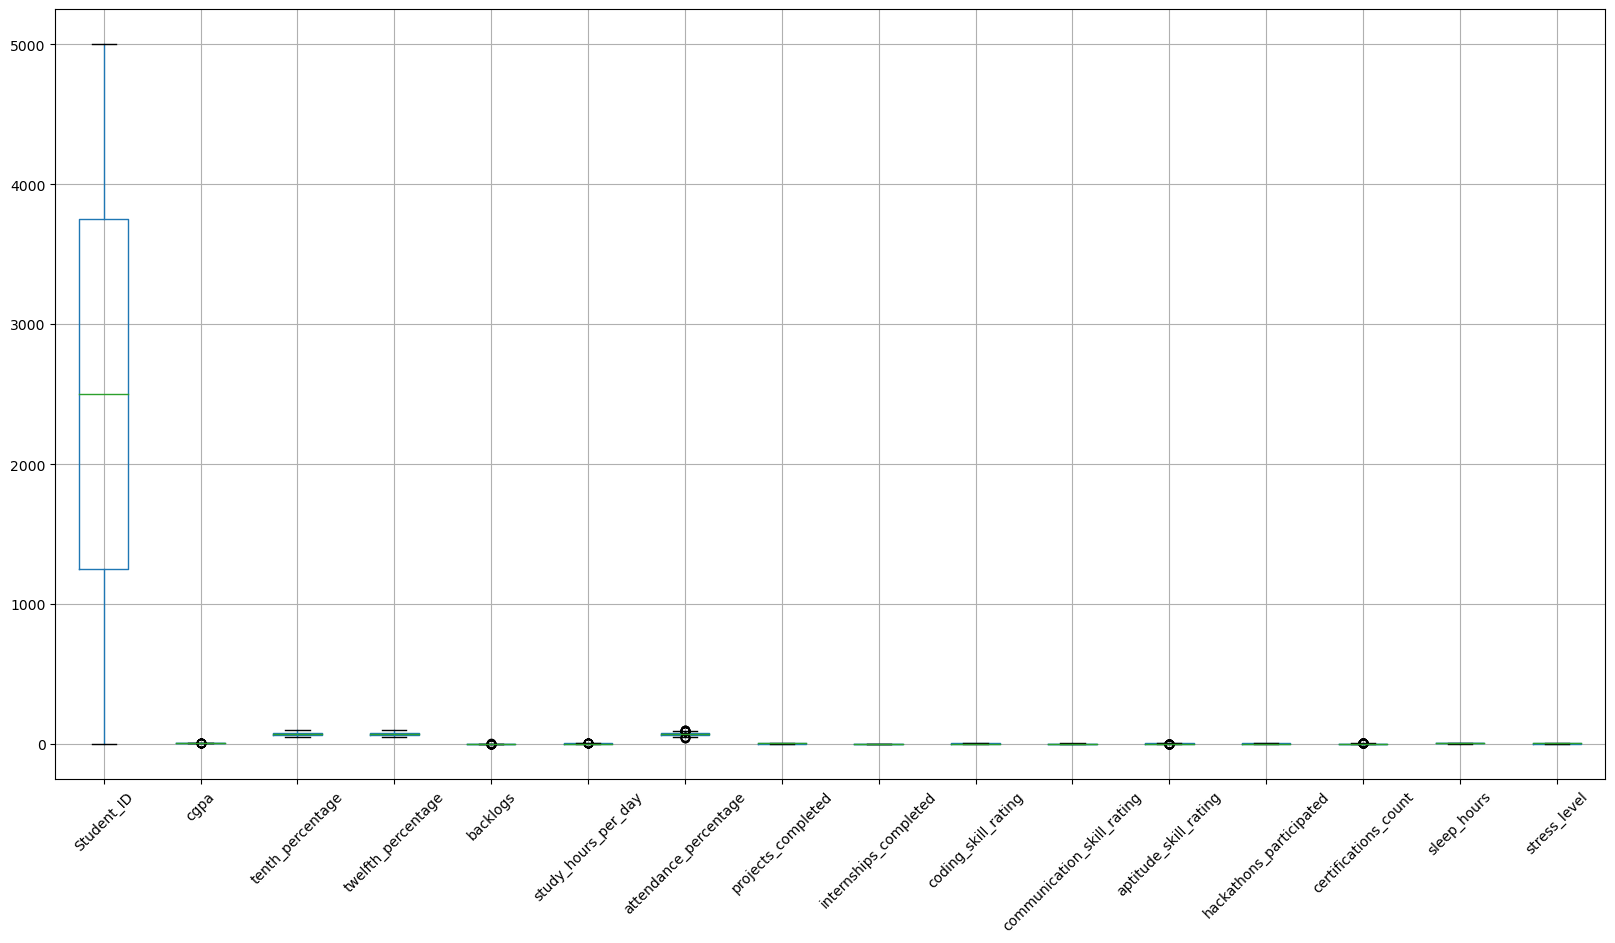

In [9]:
# plot boxplot for checking outliers
df.boxplot(figsize=(20,10))
plt.xticks(rotation=45)
plt.show()

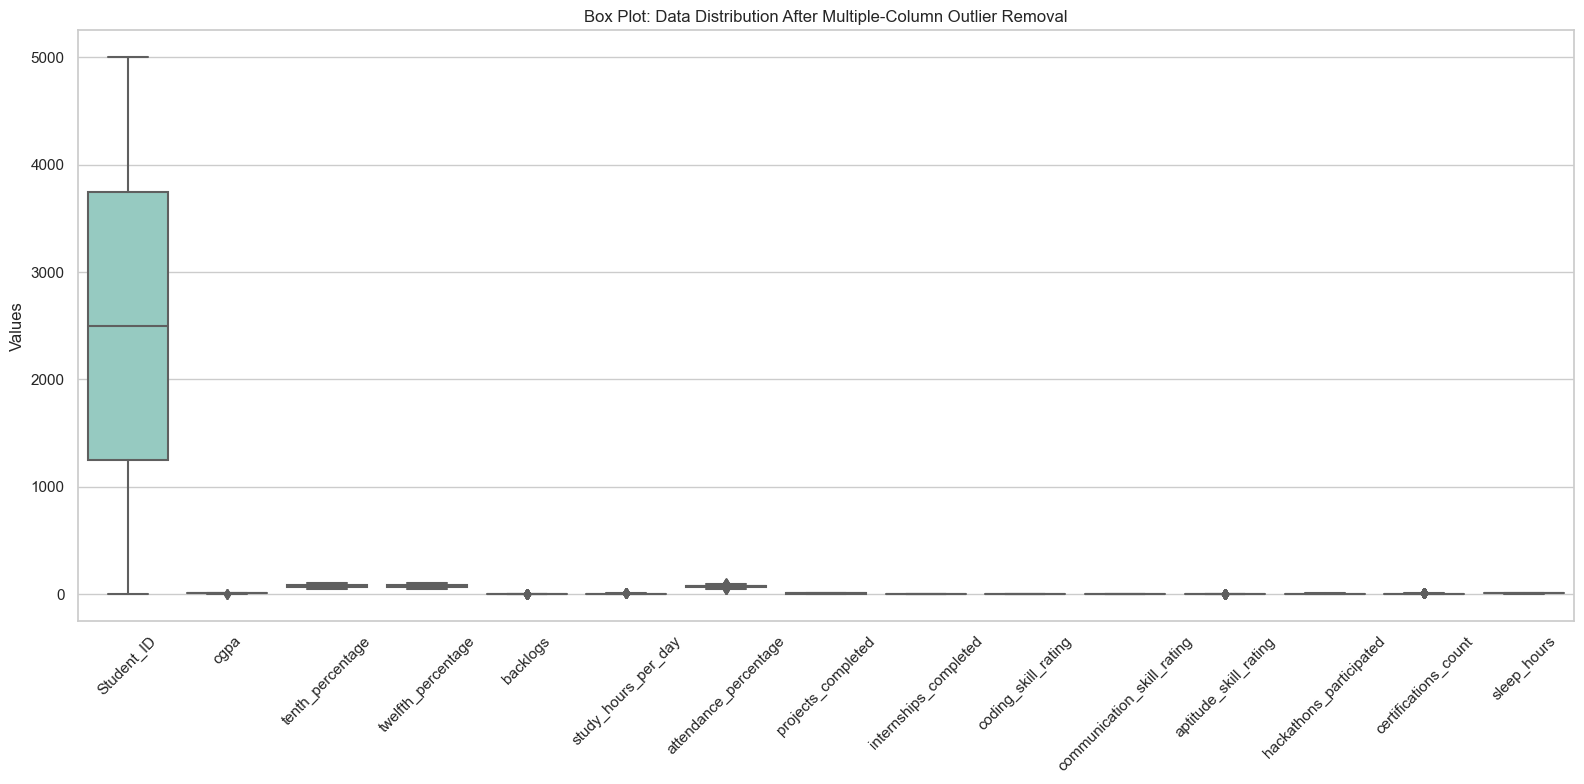

In [ ]:
# Remove outlier using IQR Method
def remove_outliers(df,columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df_cleaned = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
        return df_cleaned
cols_to_clean=['cgpa','backlogs','study_hours_per_day','attendance_percentage','aptitude_skill_rating','certifications_count']
df_final = remove_outliers(df, cols_to_clean)

plt.figure(figsize=(16, 8))
sns.set_theme(style="whitegrid")
cols_to_plot = ['Student_ID','cgpa','tenth_percentage','twelfth_percentage','backlogs','study_hours_per_day','attendance_percentage','projects_completed',
                'internships_completed','coding_skill_rating','communication_skill_rating','aptitude_skill_rating','hackathons_participated','certifications_count',
                'sleep_hours']

sns.boxplot(data=df_final[cols_to_plot], palette="Set3")

plt.xticks(rotation=45)
plt.title('Box Plot: Data Distribution After Multiple-Column Outlier Removal')
plt.ylabel('Values')
plt.tight_layout()
plt.show()

### Feature Engineering

In [11]:
df['eligible_for_scholarship'] = df['family_income_level'].astype('category').cat.codes
print(df.head())

   Student_ID  gender branch  cgpa  tenth_percentage  twelfth_percentage  \
0           1    Male    ECE  8.74              74.0                75.0   
1           2  Female    ECE  7.80              75.3                69.7   
2           3  Female     IT  6.95              62.8                68.3   
3           4    Male    ECE  7.46              57.9                51.4   
4           5    Male     IT  6.86              61.3                73.5   

   backlogs  study_hours_per_day  attendance_percentage  projects_completed  \
0         0                  3.8                   71.1                   7   
1         0                  6.3                   69.5                   5   
2         0                  1.5                   62.5                   8   
3         1                  4.7                   64.6                   6   
4         2                  5.2                   75.9                   3   

   ...  hackathons_participated  certifications_count  sleep_hours  

#### Data Understanding

In [12]:
# Basic information about the dataset
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 5000 entries, 0 to 4999
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Student_ID                   5000 non-null   int64  
 1   gender                       5000 non-null   object 
 2   branch                       5000 non-null   object 
 3   cgpa                         5000 non-null   float64
 4   tenth_percentage             5000 non-null   float64
 5   twelfth_percentage           5000 non-null   float64
 6   backlogs                     5000 non-null   int64  
 7   study_hours_per_day          5000 non-null   float64
 8   attendance_percentage        5000 non-null   float64
 9   projects_completed           5000 non-null   int64  
 10  internships_completed        5000 non-null   int64  
 11  coding_skill_rating          5000 non-null   int64  
 12  communication_skill_rating   5000 non-null   int64  
 13  aptitude_skill_rat

In [13]:
# Use summary statistics to understand distributions.
print(df.describe())

        Student_ID         cgpa  tenth_percentage  twelfth_percentage  \
count  5000.000000  5000.000000       5000.000000         5000.000000   
mean   2500.500000     8.283798         74.537400           74.543060   
std    1443.520003     1.008391         10.266752           10.244481   
min       1.000000     5.000000         50.000000           50.000000   
25%    1250.750000     7.610000         67.400000           67.600000   
50%    2500.500000     8.320000         74.700000           74.800000   
75%    3750.250000     9.020000         82.000000           81.700000   
max    5000.000000    10.000000        100.000000          100.000000   

          backlogs  study_hours_per_day  attendance_percentage  \
count  5000.000000          5000.000000            5000.000000   
mean      0.343600             4.041120              72.041560   
std       0.612547             1.967754               7.720029   
min       0.000000             0.000000              44.700000   
25%       0.

What is the distribution of CGPA among engineering students?

How does the average CGPA vary across different engineering branches?

Is there a relationship between study hours per day and CGPA?

How does attendance percentage influence CGPA?

What is the distribution of stress levels among students?

Does completing more projects improve coding skill ratings?

How does the number of internships completed affect CGPA?

Is there a relationship between family income level and student stress level?

What is the gender distribution of students in the dataset?

Do certifications contribute to higher coding skill ratings?

How does the number of backlogs impact average CGPA?

What are the key correlations among numerical features in the dataset?

How does sleep duration affect stress levels and CGPA among students?

Is there a relationship between internet access and coding skill development?

Do students from different city tiers show differences in CGPA or placement outcomes?

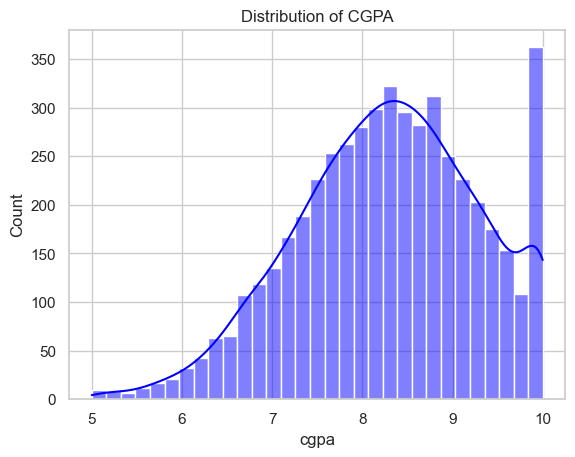

In [14]:
# 1. What is the distribution of CGPA among engineering students?
sns.histplot(df['cgpa'], kde=True, color='blue')
plt.title('Distribution of CGPA')
plt.show()

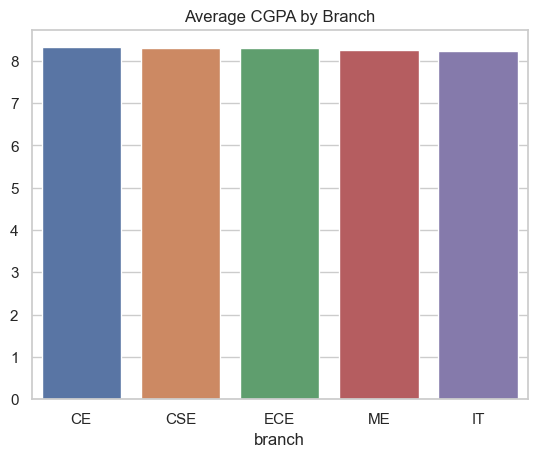

In [ ]:
# 2. How does the average CGPA vary across different engineering branches?
branch_cgpa = df.groupby('branch')['cgpa'].mean().sort_values(ascending=False)
sns.barplot(x=branch_cgpa.index, y=branch_cgpa.values)
plt.title('Average CGPA by Branch')
plt.show()

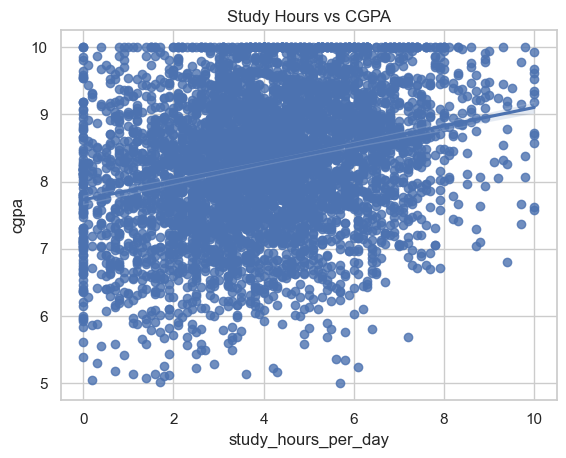

In [16]:
# 3. Is there a relationship between study hours per day and CGPA?
sns.regplot(x='study_hours_per_day', y='cgpa', data=df)
plt.title('Study Hours vs CGPA')
plt.show()


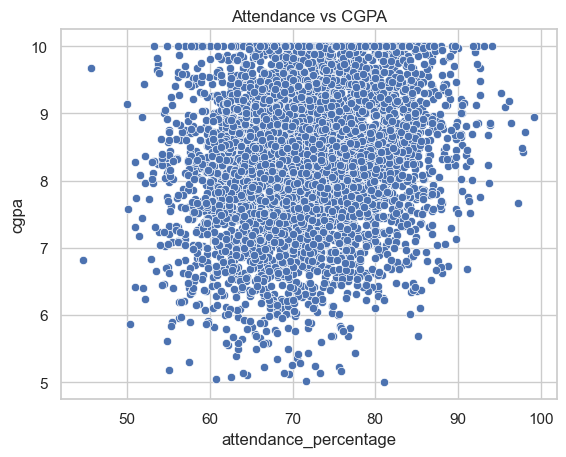

In [17]:
# 4. How does attendance percentage influence CGPA?
sns.scatterplot(x='attendance_percentage', y='cgpa', data=df)
plt.title('Attendance vs CGPA')
plt.show()


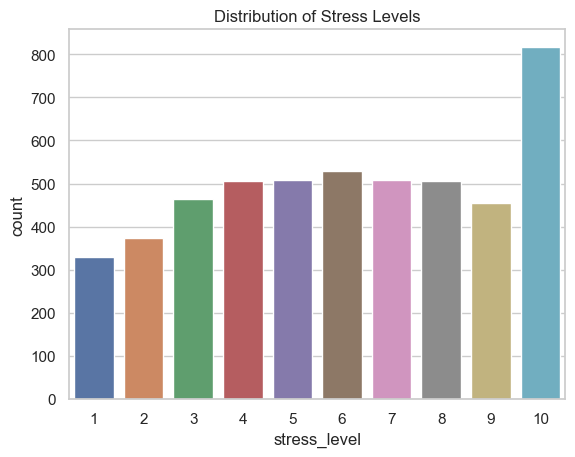

In [18]:
# 5. What is the distribution of stress levels among students?
sns.countplot(x='stress_level', data=df)
plt.title('Distribution of Stress Levels')
plt.show()


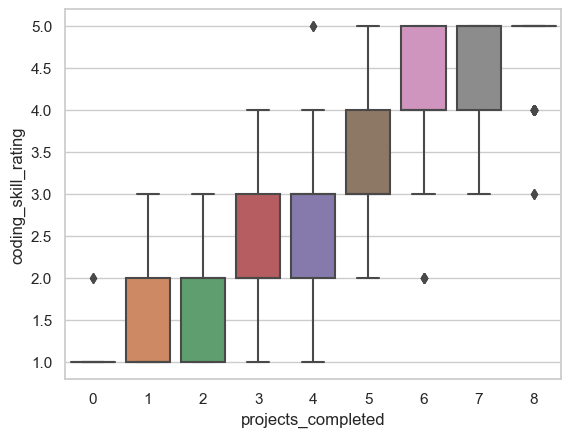

In [19]:
# 6. Does completing more projects improve coding skill ratings?
sns.boxplot(x='projects_completed', y='coding_skill_rating', data=df)
plt.show()


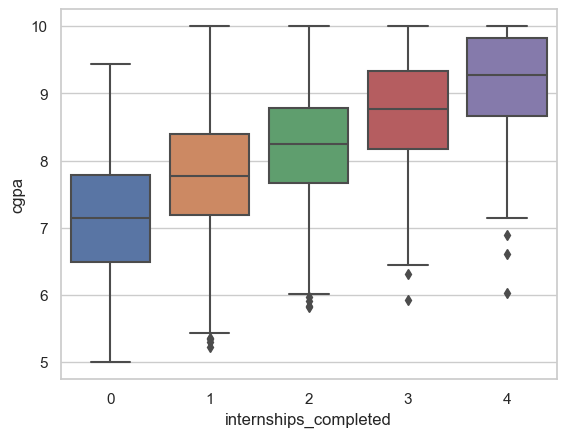

In [20]:
# 7. How does the number of internships completed affect CGPA?
sns.boxplot(x='internships_completed', y='cgpa', data=df)
plt.show()


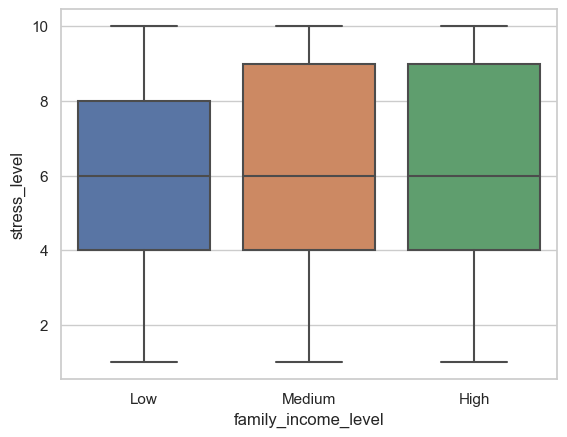

In [21]:
# 8. Is there a relationship between family income level and student stress level?
sns.boxplot(x='family_income_level', y='stress_level', data=df, order=['Low', 'Medium', 'High'])
plt.show()

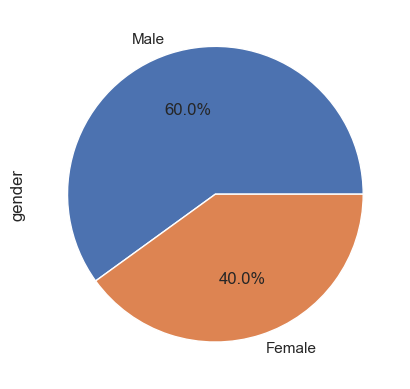

In [22]:
# 9. What is the gender distribution of students in the dataset?
df['gender'].value_counts().plot.pie(autopct='%1.1f%%')
plt.show()

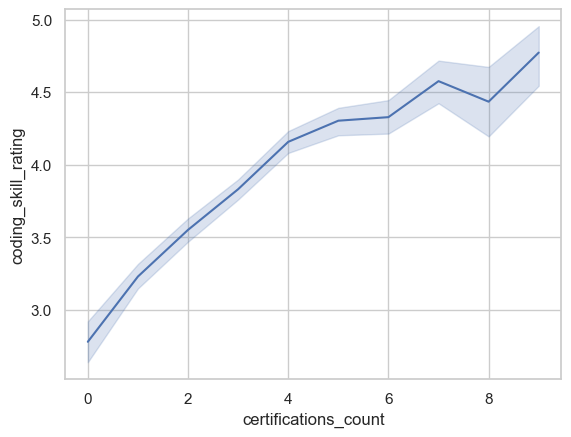

In [23]:
# 10. Do certifications contribute to higher coding skill ratings?
sns.lineplot(x='certifications_count', y='coding_skill_rating', data=df)
plt.show()


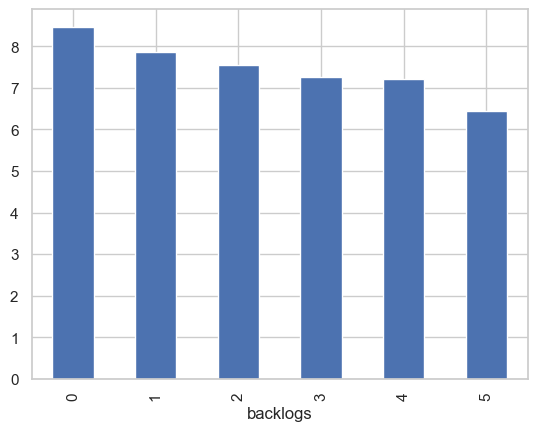

In [24]:
# 11. How does the number of backlogs impact average CGPA?
df.groupby('backlogs')['cgpa'].mean().plot(kind='bar')
plt.show()

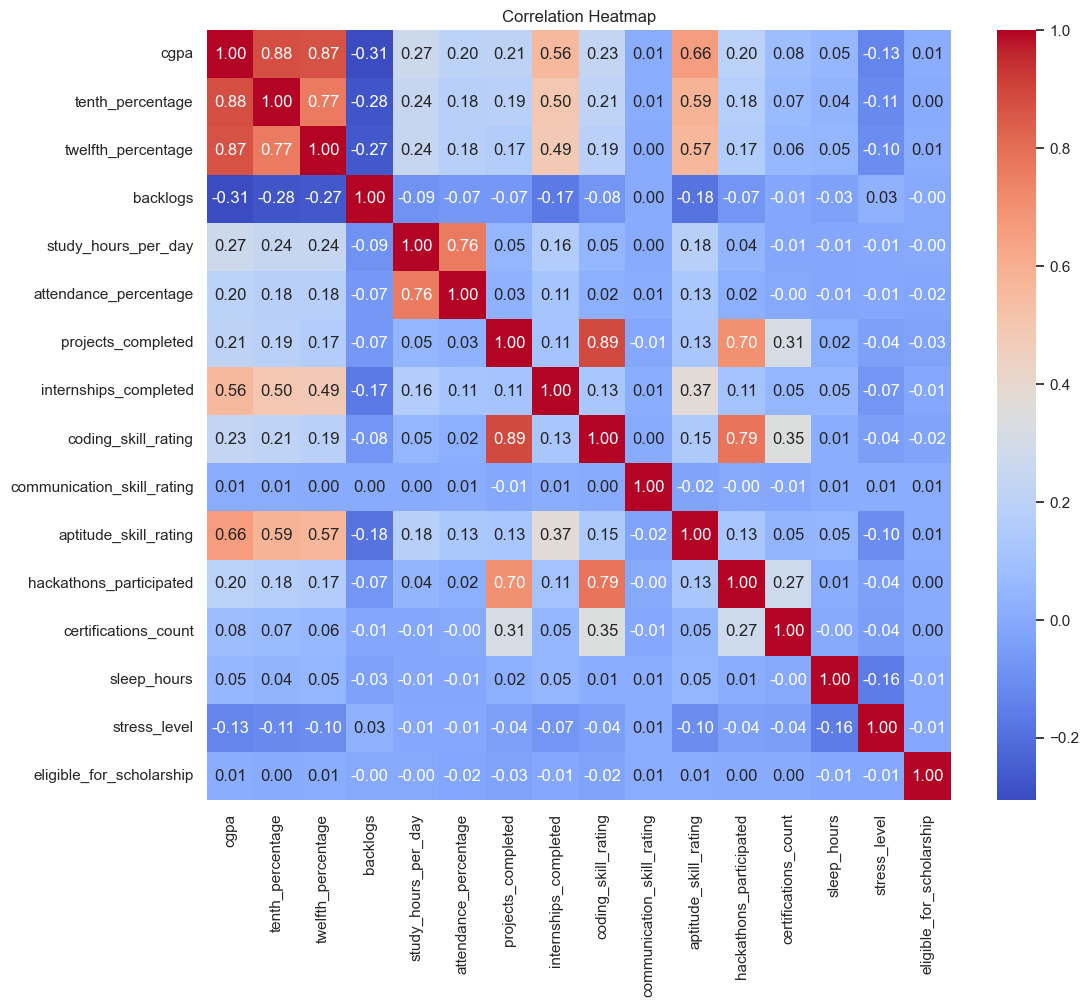

In [25]:
# 12. What are the key correlations among numerical features in the dataset?
corr = df.select_dtypes('number').drop(columns=['Student_ID']).corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()


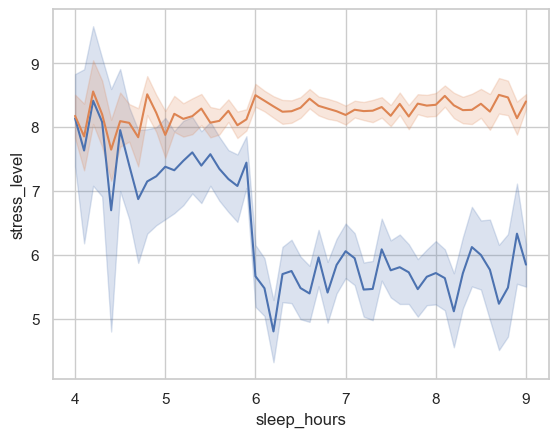

In [29]:
# 13. How does sleep duration affect stress levels and CGPA among students?
sns.lineplot(x='sleep_hours', y='stress_level', data=df)
sns.lineplot(x='sleep_hours', y='cgpa', data=df)
plt.show()

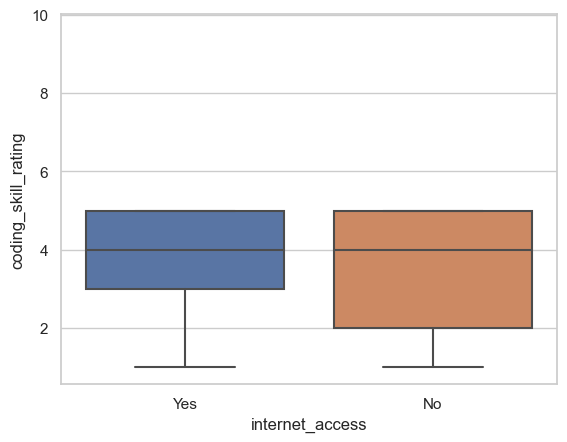

In [27]:
# 14. Is there a relationship between internet access and coding skill development?
sns.boxplot(x=('internet_access'), y='coding_skill_rating', data=df)
plt.show()

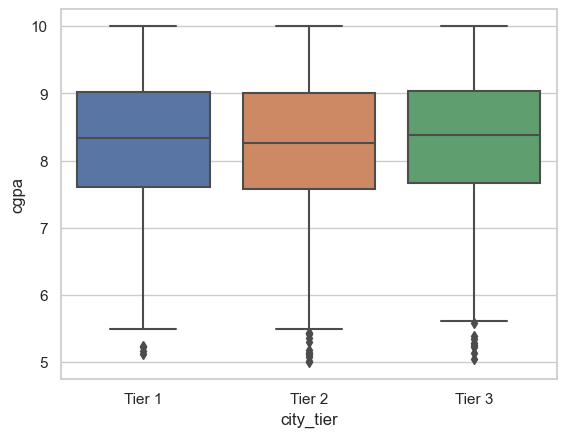

In [28]:
# 15. Do students from different city tiers show differences in CGPA or placement outcomes?
sns.boxplot(x='city_tier', y='cgpa', data=df, order=['Tier 1', 'Tier 2', 'Tier 3'])
plt.show()


### Suggestions & Recommendations

For Students

1. Maintain Consistent Study Habits : Students who study regularly and maintain good attendance tend to achieve higher CGPA. Creating a daily study routine can significantly improve academic outcomes.

2. Focus on Balanced Skill Development : Placement success is not driven by coding skills alone. Students should also work on communication and aptitude skills to improve overall employability.

3. Prioritize Adequate Sleep and Stress Management : Proper sleep duration is linked to lower stress levels and better academic performance. Students should adopt healthy lifestyles to avoid burnout.

4. Participate in Extracurricular Activities in Moderation : Moderate involvement helps in stress management and personality development, but excessive participation may affect academic focus.

For Educational Institutions

1. Encourage Internship and Industry Exposure : Colleges should collaborate with industries to provide more internship opportunities, especially for students from lower city tiers.

2. Provide Skill-Oriented Training Programs : Regular workshops on coding, aptitude, and communication can bridge the gap between academic knowledge and industry requirements.

3. Strengthen Academic Monitoring Systems : Early identification of students with backlogs can help institutions provide timely academic support and mentoring.

4. Implement Student Wellness Programs : Stress management sessions, counseling services, and time-management workshops can improve both mental health and academic performance.

For Recruiters & Policymakers

1. Support Students from Lower Socioeconomic Backgrounds : Financial assistance, scholarships, and mentorship programs can reduce stress and improve student performance and placement outcomes.

2. Promote Skill-Based Hiring : Emphasizing skill proficiency rather than CGPA alone can help identify capable candidates with strong practical knowledge.